In [ ]:
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d abdallamahgoub/diabetes

Dataset URL: https://www.kaggle.com/datasets/abdallamahgoub/diabetes
License(s): unknown
100% 8.89k/8.89k [00:00<00:00, 11.0MB/s]



In [ ]:
!unzip diabetes.zip

Archive:  diabetes.zip
  inflating: diabetes.csv            


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [ ]:
df = pd.read_csv('diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
print(X)
print(y)

     Pregnancies  Glucose  BloodPressure  ...   BMI  Pedigree  Age
0              6      148             72  ...  33.6     0.627   50
1              1       85             66  ...  26.6     0.351   31
2              8      183             64  ...  23.3     0.672   32
3              1       89             66  ...  28.1     0.167   21
4              0      137             40  ...  43.1     2.288   33
..           ...      ...            ...  ...   ...       ...  ...
763           10      101             76  ...  32.9     0.171   63
764            2      122             70  ...  36.8     0.340   27
765            5      121             72  ...  26.2     0.245   30
766            1      126             60  ...  30.1     0.349   47
767            1       93             70  ...  30.4     0.315   23

[768 rows x 8 columns]
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.8 , random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(153, 8)
(615, 8)
(153,)
(615,)


In [ ]:
model = KNeighborsClassifier(n_neighbors=5 , algorithm = 'auto')
model.fit(X_train, y_train)
y_predict = model.predict(X_test)
accuracy = accuracy_score(y_test, y_predict)
print(accuracy)

0.6829268292682927


In [ ]:
k = input("Enter the value of k: ")
model = KNeighborsClassifier(n_neighbors=int(k) , algorithm = 'auto')
model.fit(X_train, y_train)
y_predicts = model.predict(X_test)
accuracy_2 = accuracy_score(y_test, y_predicts)
print(accuracy_2)

Enter the value of k: 20
0.697560975609756


In [ ]:
#clean data
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
age = df[df['Age'] == 0]
age

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome


In [ ]:
pregnancies = df[df['Pregnancies'] == 'Nan']
pregnancies


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome


In [ ]:
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_zeros:
    num_zeros = (df[col] == 0).sum()
    print(f"Number of zero values in '{col}': {num_zeros}")

print("\nChecking for actual NaN values across the DataFrame:")
print(df.isnull().sum())

Number of zero values in 'Glucose': 5
Number of zero values in 'BloodPressure': 35
Number of zero values in 'SkinThickness': 227
Number of zero values in 'Insulin': 374
Number of zero values in 'BMI': 11

Checking for actual NaN values across the DataFrame:
Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Outcome          0
dtype: int64


In [ ]:
df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:

print("Number of NaN values per column after replacing 0s:")
print(df[columns_with_zeros].isnull().sum())


for col in columns_with_zeros:
    df[col].fillna(df[col].median(), inplace=True)

print("\nNumber of NaN values per column after imputation:")
print(df[columns_with_zeros].isnull().sum())

df.describe()

Number of NaN values per column after replacing 0s:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Number of NaN values per column after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


/tmp/ipykernel_5411/4127958527.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:

X = df.drop('Outcome', axis=1)
y = df['Outcome']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("New X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)
print("New y_train shape:", y_train.shape)
print("New y_test shape:", y_test.shape)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nFirst 5 rows of scaled X_train:")
display(X_train_scaled.head())

New X_train shape: (614, 8)
New X_test shape: (154, 8)
New y_train shape: (614,)
New y_test shape: (154,)

First 5 rows of scaled X_train:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age
0,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769477,0.310794,-0.792169
1,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417498,-0.116439,0.561034
2,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359790,-0.764862,-0.707594
3,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.402832,0.262314,-0.369293
4,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782373,-0.337630,-0.961320


In [ ]:
k_value = input("enter k : ")
model_new = KNeighborsClassifier(n_neighbors=int(k_value), algorithm='auto')
model_new.fit(X_train_scaled, y_train)

y_predict_new = model_new.predict(X_test_scaled)
accuracy_new = accuracy_score(y_test, y_predict_new)

print(f"Accuracy of KNN model with k={k_value} after cleaning and scaling: {accuracy_new}")


print("\nClassification Report:")
print(classification_report(y_test, y_predict_new))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_predict_new))

enter k : 5
Accuracy of KNN model with k=5 after cleaning and scaling: 0.7532467532467533

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154


Confusion Matrix:
[[83 17]
 [21 33]]


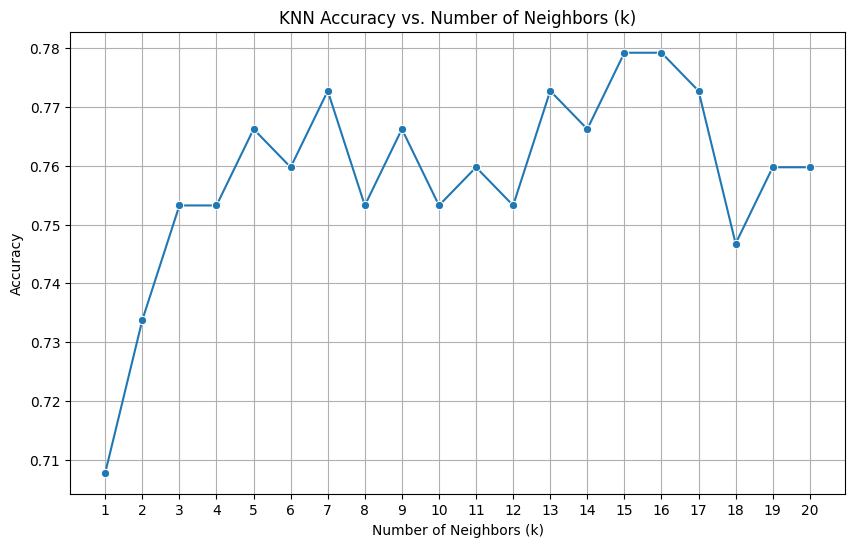

NameError: name 'metric' is not defined

In [ ]:
accuracy_scores = []
k_values = range(1, 21)

for k in k_values:
    model_k = KNeighborsClassifier(n_neighbors=k, algorithm='auto',metric = 'manhattan')
    model_k.fit(X_train_scaled, y_train)
    y_pred_k = model_k.predict(X_test_scaled)
    accuracy_scores.append(accuracy_score(y_test, y_pred_k))


plt.figure(figsize=(10, 6))
sns.lineplot(x=list(k_values), y=accuracy_scores, marker='o')
plt.title('KNN Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

# Print the k with the highest accuracy
best_k = k_values[np.argmax(accuracy_scores)]
max_accuracy = np.max(accuracy_scores)
print(f"The best 'k' value is {best_k} with an accuracy of {max_accuracy:.4f} with metric : {metric}")